In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler

In [3]:
# Descargar datos históricos de KO (Coca-Cola) desde Yahoo Finance
symbol = "KO"
data = yf.download(symbol, start="2010-01-01", end="2024-03-01")
data.columns

[*********************100%***********************]  1 of 1 completed


MultiIndex([( 'Close', 'KO'),
            (  'High', 'KO'),
            (   'Low', 'KO'),
            (  'Open', 'KO'),
            ('Volume', 'KO')],
           names=['Price', 'Ticker'])

In [4]:
# Renombrar las columnas eliminando el MultiIndex y aplicando snake_case
data.columns = [f"{col[0].lower()}_{col[1].lower()}" for col in data.columns]

# Mostrar las nuevas columnas
print(data.head())

             close_ko    high_ko     low_ko    open_ko  volume_ko
Date                                                             
2010-01-04  17.818310  17.874539  17.774576  17.855795   13870400
2010-01-05  17.602768  17.802694  17.537168  17.758959   23172400
2010-01-06  17.596510  17.630871  17.487175  17.602757   19264600
2010-01-07  17.552784  17.609013  17.415336  17.596519   13234600
2010-01-08  17.227901  17.380968  17.102948  17.324739   28712400


In [5]:
# Usamos solo el precio de cierre ajustado
df = data[['close_ko']]
df = df.rename(columns={'close_ko': 'close'})

# Normalización de datos
scaler = MinMaxScaler(feature_range=(0, 1))
df_scaled = scaler.fit_transform(df)
df_scaled

array([[0.04573682],
       [0.04091889],
       [0.04077901],
       ...,
       [0.94664891],
       [0.94794082],
       [0.93975887]])

In [ ]:
# Crear secuencias de tiempo para entrenamiento
def create_sequences(data, seq_length):
    sequences, labels = [], []
    for i in range(len(data) - seq_length):
        sequences.append(data[i:i+seq_length])
        labels.append(data[i+seq_length])
    return np.array(sequences), np.array(labels)

# Definir la longitud de la secuencia (días pasados usados para predecir)
SEQ_LENGTH = 60  # 60 días de datos para predecir el siguiente
X, y = create_sequences(df_scaled, SEQ_LENGTH)
print(X,y)

In [7]:
from sklearn.model_selection import train_test_split

# Dividir en conjuntos de entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
# Construcción del modelo LSTM en TensorFlow
model = tf.keras.Sequential([
    tf.keras.layers.LSTM(50, return_sequences=True, input_shape=(SEQ_LENGTH, 1)),
    tf.keras.layers.LSTM(50, return_sequences=False),
    tf.keras.layers.Dense(25, activation="relu"),
    tf.keras.layers.Dense(1)
])

# Compilar el modelo
model.compile(optimizer='adam', loss='mean_squared_error')

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
# Entrenar el modelo
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - loss: 0.0536 - val_loss: 5.8046e-04
Epoch 2/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - loss: 6.5571e-04 - val_loss: 4.9483e-04
Epoch 3/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - loss: 5.6530e-04 - val_loss: 5.3915e-04
Epoch 4/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - loss: 5.9681e-04 - val_loss: 4.6193e-04
Epoch 5/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - loss: 5.4367e-04 - val_loss: 4.9910e-04
Epoch 6/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - loss: 5.9727e-04 - val_loss: 3.9336e-04
Epoch 7/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - loss: 5.5069e-04 - val_loss: 4.6184e-04
Epoch 8/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - loss: 5.5991e-04 - val_loss: 3.2257e-04
Epoch 9/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - loss: 4.8541e-04 - val_loss: 3.0818e-04
Epoch 10/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - loss: 4.6610e-04 - val_loss: 3.0706e-04
Epoch 11/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - loss: 4.1341e-04 

22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step


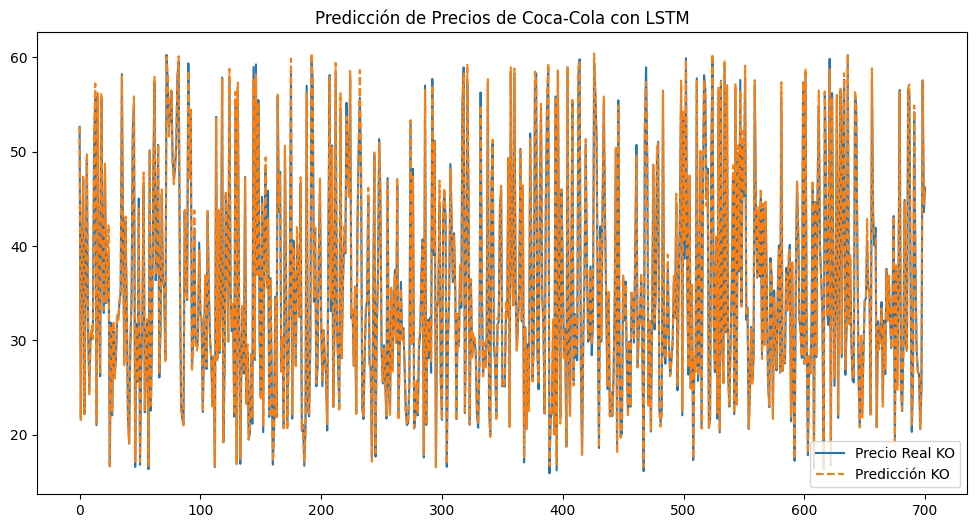

In [10]:
# Predicciones
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)

# Invertir la escala de los valores reales
real_prices = scaler.inverse_transform(y_test.reshape(-1, 1))

# Visualizar los resultados
plt.figure(figsize=(12,6))
plt.plot(real_prices, label="Precio Real KO")
plt.plot(predictions, label="Predicción KO", linestyle="dashed")
plt.legend()
plt.title("Predicción de Precios de Coca-Cola con LSTM")
plt.show()